# Pertemuan 1 — Introduction Data Science
### Praktik: EDA pertama dengan data transaksi retail

<a href="https://colab.research.google.com/github/[username]/[nama-repo]/blob/main/pertemuan-01/01_Introduction_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Ganti `[username]` dan `[nama-repo]` pada tautan di atas dengan alamat repositori GitHub kelas.

**Setelah menyelesaikan notebook ini, kamu bisa:**

1. Menjalankan kode Python di Google Colab.
2. Memuat data ke dalam *DataFrame* pandas.
3. Mengenali isi data dengan `head()`, `info()`, dan `describe()`.
4. Membuat grafik pertama: tren penjualan bulanan.
5. Mengubah pertanyaan bisnis menjadi pertanyaan data.

**Dataset:** Online Retail II (UCI Machine Learning Repository). Penjelasan lengkap kolomnya ada di `README.md`.

**Perkiraan waktu:** 55–60 menit.

---
## 0. Kenalan dengan Google Colab

Notebook terdiri dari dua jenis kotak (*cell*):

| Jenis | Isi | Cara menjalankan |
|---|---|---|
| **Teks** | Penjelasan, seperti yang sedang kamu baca | Tidak perlu dijalankan |
| **Kode** | Perintah Python | Klik tombol ▶ di kiri cell, atau tekan `Shift + Enter` |

Jalankan cell **berurutan dari atas ke bawah**. Kalau ada error, biasanya karena ada cell di atasnya yang terlewat.

Coba jalankan cell pertamamu di bawah ini.

In [ ]:
print("Halo, Data Science!")

Halo, Data Science!


Python bisa dipakai seperti kalkulator. Kita simpan nilai ke dalam **variabel**, lalu menghitung dengannya.

In [ ]:
harga_satuan = 6.95      # harga satu barang (dalam poundsterling)
jumlah = 12              # banyaknya barang yang dibeli

total = harga_satuan * jumlah
print("Total belanja:", total)

Total belanja: 83.4


Rumus sederhana di atas, **harga × jumlah**, akan kita pakai lagi nanti untuk lebih dari satu juta baris transaksi sekaligus.

---
## 1. Business case: hari pertamamu di RetailKu

Kamu baru diterima sebagai **data analyst** di *RetailKu* (perusahaan fiktif), toko online yang menjual pernak-pernik hadiah. Datanya kita pinjam dari sebuah toko online sungguhan di Inggris.

Dalam cerita ini, sekarang **awal April 2011**. Pagi ini manajermu datang ke mejamu:

> *"Penjualan kuartal pertama tahun ini turun dibanding kuartal sebelumnya. Kenapa? Apa kita perlu khawatir?"*

Seorang data analyst tidak langsung menebak. Ia mengubah pertanyaan bisnis menjadi pertanyaan yang bisa dijawab data:

| Pertanyaan bisnis | Pertanyaan data |
|---|---|
| Benarkah penjualan turun? | Berapa total penjualan tiap kuartal? |
| Seberapa besar turunnya? | Berapa persen perubahannya dibanding kuartal sebelumnya? |
| Apakah ini wajar? | Bagaimana dibanding kuartal yang sama tahun lalu? |
| Apa penyebabnya? | Yang turun jumlah transaksinya, atau nilai belanja per transaksi? |

Inilah tahap pertama dalam siklus **CRISP-DM**: *business understanding*. Sisa notebook ini adalah tahap kedua: *data understanding*.

---
## 2. Menyiapkan alat kerja

Kita memakai tiga *library* yang hampir selalu dipakai di data science:

| Library | Kegunaan | Nama panggilan |
|---|---|---|
| **pandas** | Mengolah data berbentuk tabel | `pd` |
| **numpy** | Perhitungan angka | `np` |
| **matplotlib** | Membuat grafik | `plt` |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WARNA = "#2B6F7E"   # satu warna utama untuk semua grafik

---
## 3. Mengambil data

Data disediakan UCI sebagai satu file CSV (`online_retail_II 2.xlsx - Year 2010-2011.csv`).

In [ ]:
# Hubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Tentukan path tempat Anda menyimpan file di Google Drive
path_drive = '/content/drive/MyDrive/UNIPA 2026/Meet 1/online_retail_II 2.xlsx - Year 2010-2011.csv'

Mounted at /content/drive


---
## 4. Memuat data ke pandas

In [ ]:
df = pd.read_csv(path_drive) # jika menggunakan mpunt drive
# df = pd.read_csv('online_retail_II 2.xlsx - Year 2010-2011.csv')

---
## 5. Kenalan dengan data

Tiga perintah pertama yang hampir selalu dijalankan seorang analyst saat menerima data baru:

| Perintah | Menjawab pertanyaan |
|---|---|
| `df.head()` | Seperti apa bentuk datanya? |
| `df.info()` | Kolom apa saja, tipenya apa, ada yang kosong? |
| `df.describe()` | Bagaimana sebaran angkanya? |


### 5.1 `head()`: mengintip beberapa baris pertama

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 08:26,3.39,17850.0,United Kingdom


**Satu baris = satu jenis barang dalam satu invoice (nota).** Satu invoice bisa terdiri dari banyak baris.

| Kolom | Arti |
|---|---|
| `Invoice` | Nomor nota. Jika diawali huruf **C**, transaksi tersebut dibatalkan |
| `StockCode` | Kode barang |
| `Description` | Nama barang |
| `Quantity` | Jumlah barang yang dibeli |
| `InvoiceDate` | Tanggal dan jam transaksi |
| `Price` | Harga satuan dalam poundsterling (£) |
| `CustomerID` | Nomor pelanggan |
| `Country` | Negara tempat tinggal pelanggan |

`head()` hanya menampilkan baris teratas. Supaya tidak tertipu, lihat juga baris terbawah dan contoh acak.

In [ ]:
df.tail(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France
541909,581587,POST,POSTAGE,1,12/9/11 12:50,18.00,12680.0,France


In [ ]:
df.sample(5, random_state=42)   # 5 baris acak

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
209270,555199,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,6/1/11 12:05,2.95,14606.0,United Kingdom
207110,554974,21794,CLASSIC FRENCH STYLE BASKET NATURAL,30,5/27/11 17:14,3.95,14031.0,United Kingdom
507583,579187,22356,CHARLOTTE BAG PINK POLKADOT,13,11/28/11 15:31,1.63,NaN,United Kingdom
429176,573546,21770,OPEN CLOSED METAL SIGN,2,10/31/11 13:13,4.95,15974.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/11 08:40,9.95,13502.0,United Kingdom


### 5.2 `info()`: daftar kolom, tipe data, dan kelengkapan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   CustomerID   406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Cara membaca hasil `info()`:

- **Non-Null Count** = jumlah baris yang terisi. Kalau lebih kecil dari jumlah baris total, berarti ada data kosong.
- **Dtype** = tipe data. `int64` bilangan bulat, `float64` bilangan desimal, `object` biasanya teks, `datetime64` tanggal dan waktu.

In [ ]:
#Megubah tipe data InvoiceDate ke datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Kita hitung jumlah data kosong per kolom secara langsung:

In [ ]:
kosong = df.isnull().sum()
persen = (kosong / len(df) * 100).round(2)

pd.DataFrame({"jumlah_kosong": kosong, "persen_kosong": persen})

,jumlah_kosong,persen_kosong
Invoice,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
CustomerID,135080,24.93
Country,0,0.00


💬 **Diskusi:** kolom mana yang paling banyak kosong? Menurutmu, kenapa sebuah toko online bisa punya transaksi tanpa nomor pelanggan?

### 5.3 `describe()`: ringkasan statistik

In [ ]:
df[["Quantity", "Price"]].describe().round(2)

,Quantity,Price
count,541910.00,541910.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


Perhatikan baris **min** dan **max**.

💬 **Diskusi:** bisakah jumlah barang bernilai negatif? Bisakah harga bernilai nol atau negatif? Mari kita lihat baris-baris yang aneh itu.

In [ ]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
# Berapa banyak baris yang nomor invoice-nya diawali huruf "C" (batal)?
invoice_batal = df["Invoice"].astype(str).str.startswith("C")
print("Baris transaksi batal :", invoice_batal.sum())
print("Baris Quantity negatif:", (df["Quantity"] < 0).sum())
print("Baris Price <= 0      :", (df["Price"] <= 0).sum())

Baris transaksi batal : 9288
Baris Quantity negatif: 10624
Baris Price <= 0      : 2517


Data nyata hampir tidak pernah bersih. Angka-angka "aneh" ini bukan selalu kesalahan: sebagian adalah **pembatalan dan retur**, yang memang dicatat sebagai jumlah negatif.


### 5.4 Kolom teks: berapa banyak nilai uniknya?

In [ ]:
print("Jumlah invoice unik  :", df["Invoice"].nunique())
print("Jumlah produk unik   :", df["StockCode"].nunique())
print("Jumlah pelanggan unik:", df["CustomerID"].nunique())
print("Jumlah negara        :", df["Country"].nunique())

Jumlah invoice unik  : 25900
Jumlah produk unik   : 4070
Jumlah pelanggan unik: 4372
Jumlah negara        : 38


In [ ]:
# Top 10 Negara paling sering disebut
df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8558
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [ ]:
# Top 10 Negara dengan order terbanyak
df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10)

,Invoice
Country,
United Kingdom,23494
Germany,603
France,461
EIRE,360
Belgium,119
Spain,105
Netherlands,101
Switzerland,74
Portugal,71


---
## 6. Menyiapkan data untuk analisis

Untuk menghitung penjualan, kita lakukan pembersihan **sederhana** dulu.

1. Buang baris yang persis sama (duplikat).
2. Ambil hanya penjualan: `Quantity` lebih dari 0 dan `Price` lebih dari 0.
3. Buat kolom baru `Revenue` = `Quantity` × `Price`, rumus yang sama dengan latihan di bagian 0.

In [ ]:
baris_awal = len(df)

data = df.drop_duplicates()
baris_setelah_duplikat = len(data)

data = data[(data["Quantity"] > 0) & (data["Price"] > 0)].copy()
data["Revenue"] = data["Quantity"] * data["Price"]

print(f"Baris awal                  : {baris_awal:,}")
print(f"Setelah buang duplikat      : {baris_setelah_duplikat:,}")
print(f"Setelah ambil penjualan saja: {len(data):,}")

Baris awal                  : 541,910
Setelah buang duplikat      : 536,642
Setelah ambil penjualan saja: 524,879


### Angka ringkas (KPI) toko

In [ ]:
print(f"Total revenue     : £{data['Revenue'].sum():,.0f}")
print(f"Jumlah invoice    : {data['Invoice'].nunique():,}")
print(f"Jumlah pelanggan  : {data['CustomerID'].nunique():,}")
print(f"Jumlah produk     : {data['StockCode'].nunique():,}")
print(f"Periode data      : {data['InvoiceDate'].min().date()} s.d. {data['InvoiceDate'].max().date()}")

Total revenue     : £10,642,129
Jumlah invoice    : 19,960
Jumlah pelanggan  : 4,338
Jumlah produk     : 3,922
Periode data      : 2010-12-01 s.d. 2011-12-09


---
## 7. Grafik pertama: tren penjualan bulanan

Langkahnya selalu sama: **kelompokkan → jumlahkan → gambar**.

- `dt.to_period("M")` mengubah tanggal menjadi bulan (misalnya `2010-03`).
- `groupby(...)` mengelompokkan baris per bulan.
- `sum()` menjumlahkan revenue di tiap kelompok.

In [ ]:
data["Bulan"] = data["InvoiceDate"].dt.to_period("M")

revenue_bulanan = data.groupby("Bulan")["Revenue"].sum()
revenue_bulanan.head()

,Revenue
Bulan,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491


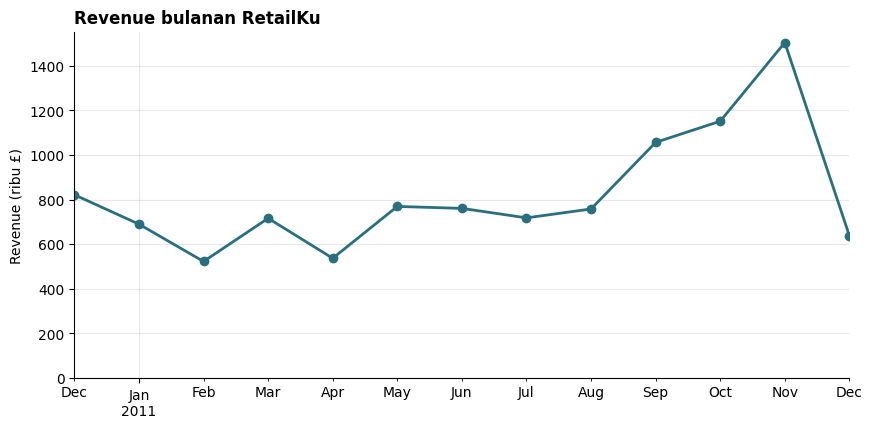

In [ ]:
ax = (revenue_bulanan / 1000).plot(kind="line", marker="o", color=WARNA, linewidth=2)

ax.set_title("Revenue bulanan RetailKu", loc="left", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Revenue (ribu £)")
ax.set_ylim(bottom=0)
plt.show()

💬 **Diskusi:**

1. Bulan apa yang penjualannya paling tinggi?
2. Toko ini menjual pernak-pernik hadiah. Adakah momen dalam setahun yang membuat orang banyak membeli hadiah?
3. Titik paling kanan terlihat jatuh tajam. Sebelum panik, cek kembali **tanggal terakhir** pada data. Apakah bulan terakhir datanya lengkap satu bulan?

---
## 8. Menjawab pertanyaan manajer

### 8.1 Benarkah penjualan Desember turun? Seberapa besar?

Kita buat tabel revenue per bulan, lalu hitung persen perubahannya dibanding bulan sebelumnya dengan `pct_change()`.

In [47]:
per_bulan = data.groupby("Bulan").agg(
    revenue=("Revenue", "sum"),
    jumlah_invoice=("Invoice", "nunique"),
)
per_bulan["revenue"] = per_bulan["revenue"].round(0)
per_bulan["perubahan_%"] = (per_bulan["revenue"].pct_change() * 100).round(1)

per_bulan

,revenue,jumlah_invoice,perubahan_%
Bulan,,,
2010-12,821453.0,1559,NaN
2011-01,689812.0,1086,-16.0
2011-02,522546.0,1100,-24.2
2011-03,716215.0,1454,37.1
2011-04,536968.0,1246,-25.0
2011-05,769297.0,1681,43.3
2011-06,760547.0,1533,-1.1
2011-07,718076.0,1475,-5.6
2011-08,757841.0,1361,5.5


💬 **Diskusi:** lihat baris terakhir (`2011-12`). Berapa persen perubahannya dibanding November? Kalau hanya melihat angka ini, apa yang akan kamu laporkan ke manajer?

### 8.2 Apakah perbandingannya adil?

Sebelum melapor, analyst yang baik memeriksa **kelengkapan data**. Kapan transaksi pertama dan terakhir tercatat?

In [48]:
print("Transaksi pertama :", data["InvoiceDate"].min())
print("Transaksi terakhir:", data["InvoiceDate"].max())

Transaksi pertama : 2010-12-01 08:26:00
Transaksi terakhir: 2011-12-09 12:50:00


In [49]:
data["Tanggal"] = data["InvoiceDate"].dt.date

kelengkapan = data.groupby("Bulan").agg(
    tanggal_pertama=("Tanggal", "min"),
    tanggal_terakhir=("Tanggal", "max"),
    hari_bertransaksi=("Tanggal", "nunique"),
)
kelengkapan

,tanggal_pertama,tanggal_terakhir,hari_bertransaksi
Bulan,,,
2010-12,2010-12-01,2010-12-23,20
2011-01,2011-01-04,2011-01-31,24
2011-02,2011-02-01,2011-02-28,24
2011-03,2011-03-01,2011-03-31,27
2011-04,2011-04-01,2011-04-28,21
2011-05,2011-05-01,2011-05-31,25
2011-06,2011-06-01,2011-06-30,26
2011-07,2011-07-01,2011-07-31,26
2011-08,2011-08-01,2011-08-31,26


### 8.3 Membandingkan dengan adil

**Cara pertama: rata-rata revenue per hari.** Total revenue dibagi jumlah hari bertransaksi, sehingga bulan yang datanya belum lengkap tetap bisa dibandingkan.

In [50]:
per_bulan["hari_bertransaksi"] = kelengkapan["hari_bertransaksi"]
per_bulan["revenue_per_hari"] = (per_bulan["revenue"] / per_bulan["hari_bertransaksi"]).round(0)

per_bulan[["revenue", "hari_bertransaksi", "revenue_per_hari"]]

,revenue,hari_bertransaksi,revenue_per_hari
Bulan,,,
2010-12,821453.0,20,41073.0
2011-01,689812.0,24,28742.0
2011-02,522546.0,24,21773.0
2011-03,716215.0,27,26526.0
2011-04,536968.0,21,25570.0
2011-05,769297.0,25,30772.0
2011-06,760547.0,26,29252.0
2011-07,718076.0,26,27618.0
2011-08,757841.0,26,29148.0


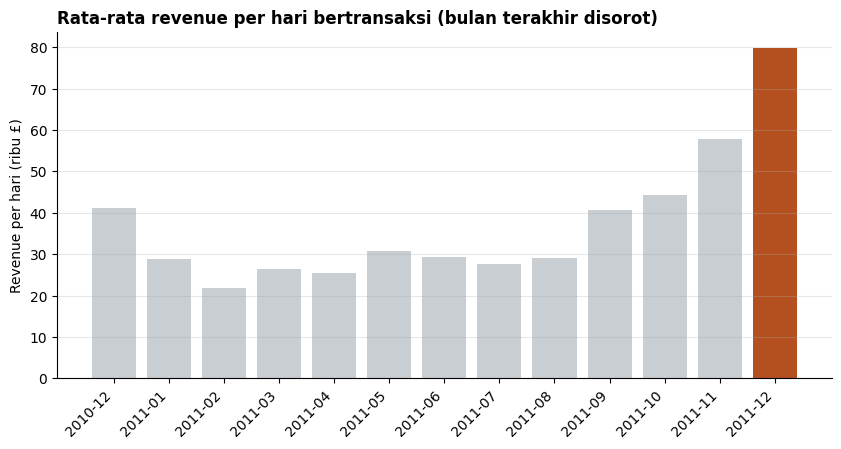

In [51]:
label = per_bulan.index.astype(str)
warna_batang = ["#C9CED2"] * len(per_bulan)     # abu-abu untuk semua bulan
warna_batang[-1] = "#B4501F"                    # sorot bulan yang ditanyakan manajer

fig, ax = plt.subplots()
ax.bar(label, per_bulan["revenue_per_hari"] / 1000, color=warna_batang)
ax.set_title("Rata-rata revenue per hari bertransaksi (bulan terakhir disorot)", loc="left", fontweight="bold")
ax.set_ylabel("Revenue per hari (ribu £)")
ax.grid(axis="x", visible=False)
plt.xticks(rotation=45, ha="right")
plt.show()

💬 **Diskusi:** bandingkan grafik ini dengan grafik revenue bulanan di bagian 7. Apakah Desember 2011 masih terlihat "jatuh"?

**Cara kedua: bandingkan periode yang sama.** Kita ambil hanya **tanggal 1 sampai 9** dari tiga bulan: Desember 2010 (tahun lalu), November 2011 (bulan lalu), dan Desember 2011 (bulan ini).

In [53]:
tiga_bulan = ["2010-12", "2011-11", "2011-12"]

awal_bulan = data[
    (data["InvoiceDate"].dt.day <= 9)
    & (data["Bulan"].astype(str).isin(tiga_bulan))
]

banding = awal_bulan.groupby("Bulan").agg(
    revenue=("Revenue", "sum"),
    jumlah_invoice=("Invoice", "nunique"),
    jumlah_pelanggan=("CustomerID", "nunique"),
    hari_bertransaksi=("Tanggal", "nunique"),
)
banding["rata2_per_invoice"] = banding["revenue"] / banding["jumlah_invoice"]
banding["rata2_per_customer"] = banding["revenue"] / banding["jumlah_pelanggan"]

banding.round(0)

,revenue,jumlah_invoice,jumlah_pelanggan,hari_bertransaksi,rata2_per_invoice,rata2_per_customer
Bulan,,,,,,
2010-12,437631.0,834,573,8,525.0,764.0
2011-11,452458.0,781,620,8,579.0,730.0
2011-12,637808.0,819,615,8,779.0,1037.0


💬 **Diskusi:**

- Untuk tanggal 1–9, bagaimana revenue Desember 2011 dibanding November 2011?
- Bagaimana dibanding Desember tahun lalu?

---
## 9. Eksplorasi tambahan

### 9.1 Dari negara mana penjualan berasal?

In [ ]:
revenue_negara = data.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

porsi_teratas = revenue_negara.iloc[0] / revenue_negara.sum() * 100
print(f"Negara teratas: {revenue_negara.index[0]} ({porsi_teratas:.1f}% dari total revenue)")

Negara teratas: United Kingdom (84.6% dari total revenue)


Satu negara sangat mendominasi, sehingga negara lain nyaris tidak terlihat jika digambar bersama. Karena itu grafik berikut menampilkan 10 negara teratas **di luar** negara terbesar.

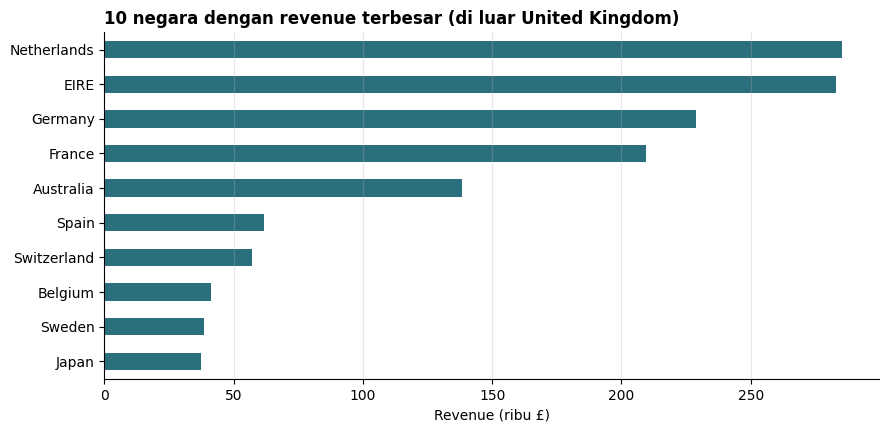

In [ ]:
top10 = revenue_negara.iloc[1:11].sort_values()       # urutkan agar batang terbesar di atas

ax = (top10 / 1000).plot(kind="barh", color=WARNA)
ax.set_title(f"10 negara dengan revenue terbesar (di luar {revenue_negara.index[0]})",
             loc="left", fontweight="bold")
ax.set_xlabel("Revenue (ribu £)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
plt.show()

### 9.2 Produk apa yang paling menghasilkan?

In [ ]:
top_produk = (
    data.groupby("Description")["Revenue"].sum()
    .sort_values(ascending=False)
    .head(10)
)
top_produk.round(0)

,Revenue
Description,
DOTCOM POSTAGE,206249.0
REGENCY CAKESTAND 3 TIER,174157.0
"PAPER CRAFT , LITTLE BIRDIE",168470.0
WHITE HANGING HEART T-LIGHT HOLDER,106237.0
PARTY BUNTING,99445.0
JUMBO BAG RED RETROSPOT,94160.0
MEDIUM CERAMIC TOP STORAGE JAR,81701.0
POSTAGE,78120.0
Manual,77753.0


---
## 10. Latihan mandiri

Kerjakan di cell kosong yang disediakan. Petunjuk diberikan, tetapi kodenya kamu tulis sendiri.



**Latihan 1.** Tampilkan 10 baris pertama data untuk pelanggan dari negara `Germany`.
*Petunjuk:* `data[data["Country"] == "..."]`

In [ ]:
# Tulis jawaban Latihan 1 di sini

**Latihan 2.** Hari apa yang paling ramai transaksi? Hitung jumlah invoice unik per nama hari, lalu buat grafik batangnya.
*Petunjuk:* `data["InvoiceDate"].dt.day_name()` menghasilkan nama hari.

In [ ]:
# Tulis jawaban Latihan 2 di sini

**Latihan 3.** Jam berapa toko paling sibuk? Buat grafik jumlah invoice unik per jam.
*Petunjuk:* `data["InvoiceDate"].dt.hour`

In [ ]:
# Tulis jawaban Latihan 3 di sini

**Latihan 4.** Siapa 5 pelanggan dengan total belanja terbesar? Berapa persen kontribusi mereka terhadap total revenue?
*Petunjuk:* tiru cara menghitung `revenue_negara`, ganti kolom pengelompoknya.

In [ ]:
# Tulis jawaban Latihan 4 di sini

**Latihan 5 (tantangan).** Buat ulang grafik revenue bulanan, tetapi **tanpa** bulan terakhir yang datanya tidak lengkap. Apakah kesan grafiknya berubah?
*Petunjuk:* `revenue_bulanan.iloc[:-1]` mengambil semua baris kecuali yang terakhir.

In [ ]:
# Tulis jawaban Latihan 5 di sini

---
## Rangkuman

| Yang kamu lakukan | Perintah kunci | Tahap CRISP-DM |
|---|---|---|
| Memahami pertanyaan manajer | (tanpa kode) | Business understanding |
| Memuat data | `pd.read_excel()`, `pd.concat()` | Data understanding |
| Mengenali data | `head()`, `info()`, `describe()`, `isnull()` | Data understanding |
| Pembersihan sederhana | `drop_duplicates()`, filter baris | Data preparation |
| Merangkum & menggambar | `groupby()`, `sum()`, `plot()` | Data understanding |
